<a href="https://colab.research.google.com/github/Lanchenba-Mayanglambam/Data_Science-Amit-Sir/blob/main/lect_11_DS_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Finance Data Mini Project

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_excel("financial_loan.xlsx")
display(df.head())

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


## Metadata

In [10]:
# shape gives numbers of rows and column
# info gives info about data
print(df.shape)
df.info()

(38576, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  object        
 2   application_type       38576 non-null  object        
 3   emp_length             38576 non-null  object        
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  object        
 6   home_ownership         38576 non-null  object        
 7   issue_date             38576 non-null  datetime64[ns]
 8   last_credit_pull_date  38576 non-null  datetime64[ns]
 9   last_payment_date      38576 non-null  datetime64[ns]
 10  loan_status            38576 non-null  object        
 11  next_payment_date      38576 non-null  datetime64[ns]
 12  member_id              38576 non-null  int64    

In [12]:
# describe gives stats
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007040,2021-06-08 13:36:34.193280512,2021-06-26 09:52:08.909166080,2021-07-26 20:42:20.605557760,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


## Total Number of Application

In [19]:
# counting number of unique id loan
number_of_loans = df["id"].nunique()
print(number_of_loans)

38576


In [51]:
# to find number o application recieved on the month June by usind Timestamp function

current_date = pd.Timestamp.today()
current_month = current_date.month
current_day = current_date.day



# to find number o application recieved on the month June by usind Timestamp function
# app_in_current_month = df[df["issue_date"].dt.month == current_month]
# number_of_app_in_current_month = app_in_current_month["id"].nunique()



# to find number application recieved on the month June upto today
app_in_current_month = df[(df["issue_date"].dt.month == current_month) & (df["issue_date"].dt.day <= current_day) ]
number_of_app_in_current_month = app_in_current_month["id"].nunique()




print(number_of_app_in_current_month)

3184


In [59]:
# amount invested in current month
current_date = pd.Timestamp.today()
current_month = current_date.month
current_day = current_date.day

num_of_app_in_current_month = df[(df["issue_date"].dt.month == current_month) & (df["issue_date"].dt.day <= current_day) ]
amount_invested_in_current_month = num_of_app_in_current_month["loan_amount"].sum()

amount_in_current_month_in_millions = amount_invested_in_current_month/1000000

amount_in_current_month_in_millions = round(amount_in_current_month_in_millions, 2)

print(f'Total invested amount in millions : ${amount_in_current_month_in_millions}M')


Total invested amount in millions : $34.16M


## Good Loan Analysis

In [89]:
# finding good loan and bad loan


# total_status_of_loan = df.groupby("loan_status")["id"].agg("count")
# print(total_status_of_loan)


# bad_loan = total_status_of_loan["Charged Off"]
# print("Bad Loans : ",bad_loan)


# good_loan = total_status_of_loan["Fully Paid"] + total_status_of_loan["Current"]
# print("Good Loans : ",good_loan)


loan_status_data = df.groupby('loan_status').agg({
    'id' : 'count',
    'dti' : 'mean',
    'int_rate' : 'mean',
    'loan_amount' : 'sum',
    'total_payment' : 'sum'
})

# rename
loan_status_data.rename(columns = {"id" : "Number of Application"},inplace = True)
display(loan_status_data)


# total application of good_loan
good_loan = loan_status_data.loc["Fully Paid","Number of Application"] + loan_status_data.loc["Current","Number of Application"]
print("Good Loans Toatal number of application : ",good_loan)


# good_loan application percentage
good_loan_Application_percentage = good_loan/(good_loan + bad_loan) * 100
print(f'Good Loan Application Percentage : {good_loan_Application_percentage:.2f}%')


# good_loan funded amount
good_loan_funded_amount = loan_status_data.loc["Fully Paid","loan_amount"] + loan_status_data.loc["Current","loan_amount"]
print(f'Good Loan Funded Amount : ${good_loan_funded_amount:,.2f}')



# good_loan total recieved amount
good_loan_total_recieved_amount = loan_status_data.loc["Fully Paid","total_payment"] + loan_status_data.loc["Current","total_payment"]
print(f'Good Loan Total Recieved Amount : ${good_loan_total_recieved_amount:,.2f}')





,Number of Application,dti,int_rate,loan_amount,total_payment
loan_status,,,,,
Charged Off,5333,0.140047,0.138786,65532225,37284763
Current,1098,0.147243,0.150993,18866500,24199914
Fully Paid,32145,0.131674,0.116411,351358350,411586256


Good Loans Toatal number of application :  33243
Good Loan Application Percentage : 86.18%
Good Loan Funded Amount : $370,224,850.00
Good Loan Total Recieved Amount : $435,786,170.00


## Bad Loan Analysis

In [90]:
# total application of bad_loan
bad_loan = loan_status_data.loc["Charged Off","Number of Application"]
print("Bad Loans Toatal number of application : ",bad_loan)


# bad_loan application percentage
bad_loan_Application_percentage = bad_loan/(good_loan + bad_loan) * 100
print(f'Bad Loan Application Percentage : {bad_loan_Application_percentage:.2f}%')


# bad_loan funded amount
bad_loan_funded_amount = loan_status_data.loc["Charged Off","loan_amount"]
print(f'Bad Loan Funded Amount : ${bad_loan_funded_amount:,.2f}')


# bad_loan total recieved amount
bad_loan_total_recieved_amount = loan_status_data.loc["Charged Off","total_payment"]
print(f'Bad Loan Total Recieved Amount : ${bad_loan_total_recieved_amount:,.2f}')

Bad Loans Toatal number of application :  5333
Bad Loan Application Percentage : 13.82%
Bad Loan Funded Amount : $65,532,225.00
Bad Loan Total Recieved Amount : $37,284,763.00


## Issue Date and Total Payment Analysis Using Graph

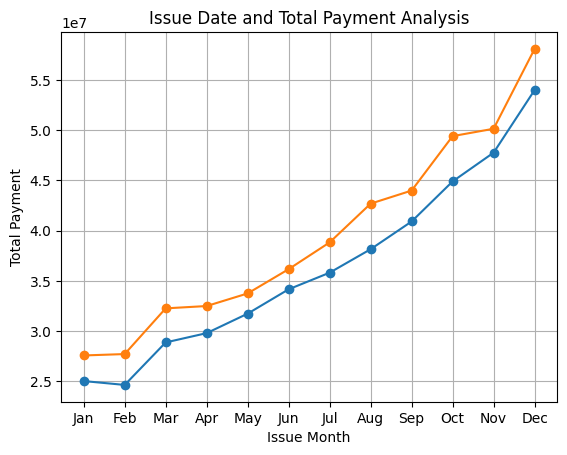

In [109]:
df["month"] = df["issue_date"].dt.month
new_df = df.groupby("month",as_index=False)["loan_amount"].sum()
new1_df = df.groupby("month",as_index=False)["total_payment"].sum()

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

x = months
y = new_df["loan_amount"]



plt.plot(x,y, marker = 'o')
plt.plot(x,new1_df["total_payment"], marker = 'o')



plt.title("Issue Date and Total Payment Analysis")
plt.xlabel("Issue Month")
plt.ylabel("Total Payment")
plt.grid()
plt.show()